 ## Importing Libraries
 ## Importing Numpy, pandas, matplotlib and seaborn for data handling and visualization 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="Set2")

## Loading the Dataset
Reading in the customer churn data to begin exploring it.

In [3]:
df = pd.read_csv("data.csv")
print(df.head(6))

   id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   0    Male              0     Yes        Yes      29          Yes   
1   1    Male              0     Yes        Yes      58          Yes   
2   2    Male              0     Yes         No      58          Yes   
3   3  Female              0      No         No       1          Yes   
4   4  Female              0      No         No       1          Yes   
5   5    Male              0     Yes        Yes       1          Yes   

  MultipleLines InternetService       OnlineSecurity  ...  \
0            No             DSL                  Yes  ...   
1            No             DSL                  Yes  ...   
2           Yes     Fiber optic                   No  ...   
3            No     Fiber optic                   No  ...   
4            No     Fiber optic                   No  ...   
5            No              No  No internet service  ...   

      DeviceProtection          TechSupport          StreamingTV  \

## Dataset Size
Checking the number of rows and columns in the dataset.

In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 594194, Columns: 21


## Data Types and Structure
Reviewing column data types and checking for missing values at a glance.

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

## Checking for Missing Values
Confirming whether any columns contain null/missing data that needs handling.

In [7]:
print(df.isnull().sum())

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Statistical Summary
Reviewing summary statistics (mean, min, max, etc.) for the numeric columns.

In [8]:
print(df.describe())

                  id  SeniorCitizen         tenure  MonthlyCharges  \
count  594194.000000  594194.000000  594194.000000   594194.000000   
mean   297096.500000       0.114102      36.577258       65.866223   
std    171529.177263       0.317936      25.061922       31.067444   
min         0.000000       0.000000       1.000000       18.250000   
25%    148548.250000       0.000000      12.000000       29.900000   
50%    297096.500000       0.000000      35.000000       74.100000   
75%    445644.750000       0.000000      62.000000       90.800000   
max    594193.000000       1.000000      72.000000      118.750000   

        TotalCharges  
count  594194.000000  
mean     2494.377057  
std      2353.916710  
min        18.800000  
25%       639.650000  
50%      1433.650000  
75%      4263.800000  
max      8684.800000  


## Checking for Duplicates
Confirming there are no duplicate rows in the dataset.

In [21]:
print("Duplicate:", df.duplicated().sum())

Duplicate: 0


## Separating Numeric and Categorical Columns
Splitting columns into numeric and categorical groups to guide the type of analysis used for each.

In [9]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['string']).columns
print("Numeric Columns:", numeric_columns)
print("Categorical Columns:", categorical_columns)


Numeric Columns: Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical Columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


## Categorical Value Distribution
Checking the percentage breakdown of each category within the categorical columns.

In [26]:
for col in categorical_columns:
    print(f"Column: {col}")
    print(df[col].value_counts(normalize=True) * 100)
    print("------")


Column: gender
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64
------
Column: Partner
Partner
Yes    52.096453
No     47.903547
Name: proportion, dtype: float64
------
Column: Dependents
Dependents
No     69.735137
Yes    30.264863
Name: proportion, dtype: float64
------
Column: PhoneService
PhoneService
Yes    93.890716
No      6.109284
Name: proportion, dtype: float64
------
Column: MultipleLines
MultipleLines
No                  47.692168
Yes                 46.198548
No phone service     6.109284
Name: proportion, dtype: float64
------
Column: InternetService
InternetService
Fiber optic    45.841257
DSL            30.475064
No             23.683679
Name: proportion, dtype: float64
------
Column: OnlineSecurity
OnlineSecurity
No                     48.717086
Yes                    27.599235
No internet service    23.683679
Name: proportion, dtype: float64
------
Column: OnlineBackup
OnlineBackup
No                     42.087769
Yes                    

## Churn Distribution
Visualizing how many customers churned versus stayed.

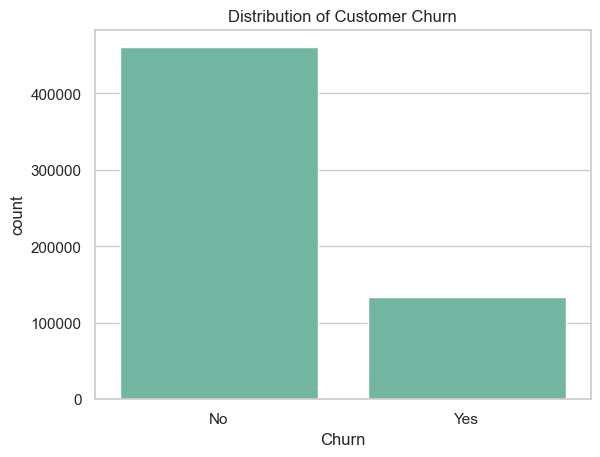

In [28]:
sns.countplot(x='Churn', data=df)
plt.title("Distribution of Customer Churn")
plt.show() 


## Distribution of Numeric Variables
Examining the distribution shape of tenure, MonthlyCharges, and TotalCharges.

- Tenure shows a bimodal pattern — many customers leave early (0–10 months), while a separate large group stays long-term (70+ months).
- MonthlyCharges shows a large cluster of customers on cheap/basic plans (~$20), with a smaller premium group spread across $60–$100.
- TotalCharges is concentrated at low values, since many customers are new and haven't accumulated high charges yet.

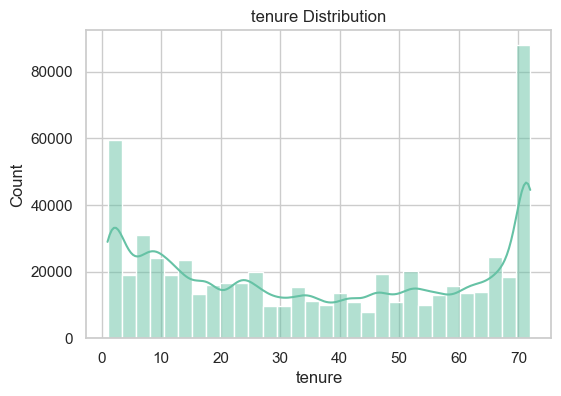

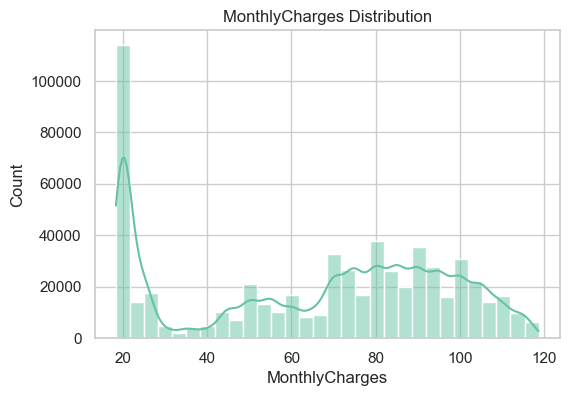

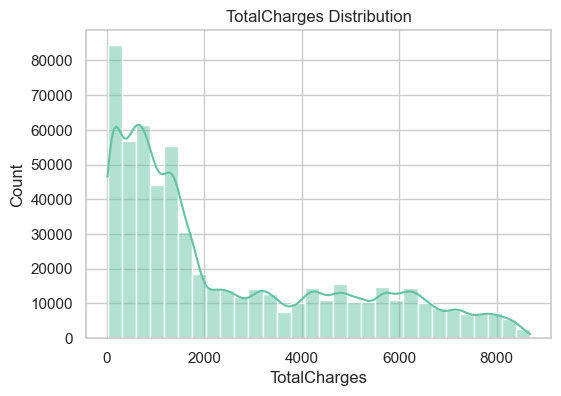

In [30]:
numeric_variables = ['tenure', 'MonthlyCharges', 'TotalCharges']
for variable in numeric_variables:
    plt.figure(figsize=(6,4))
    sns.histplot(df[variable], kde=True, bins=30) 
    plt.title(f"{variable} Distribution")
    plt.show()

## Categorical Variables Overview
Reviewing the distribution of each categorical variable across the dataset.

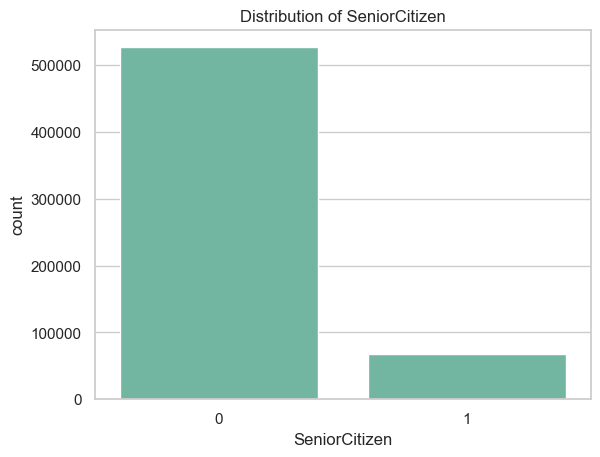

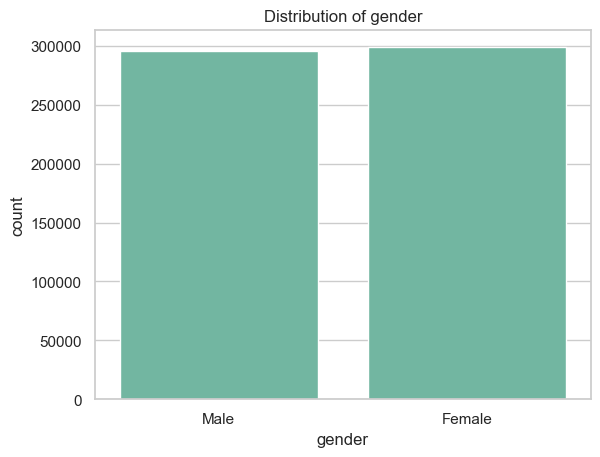

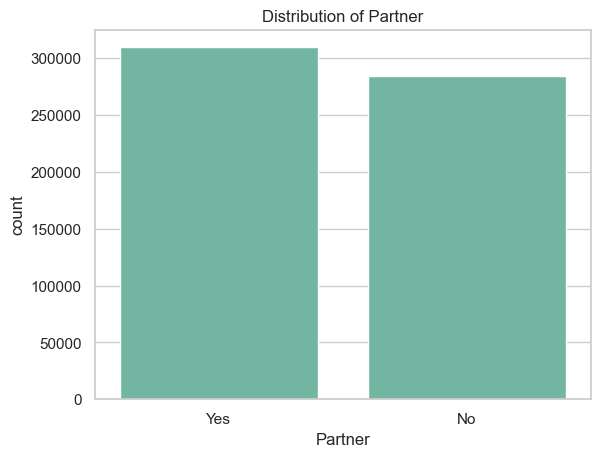

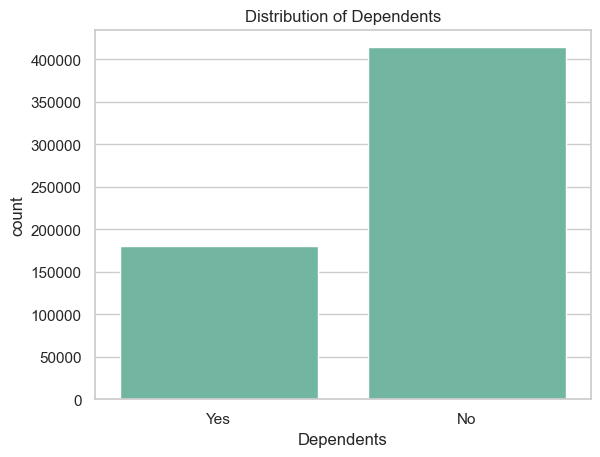

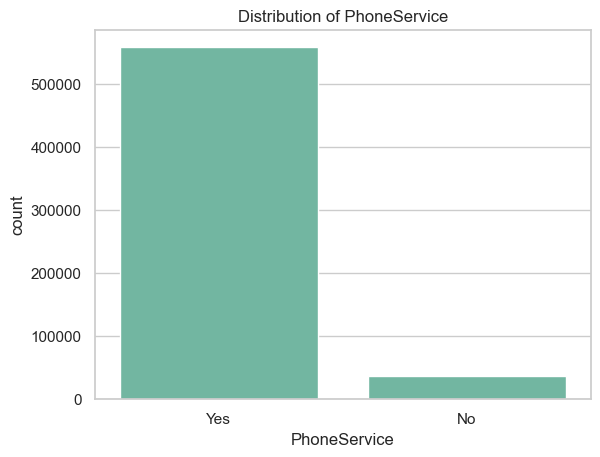

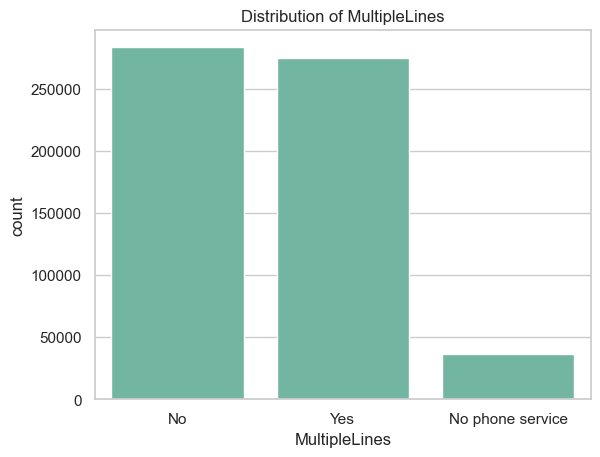

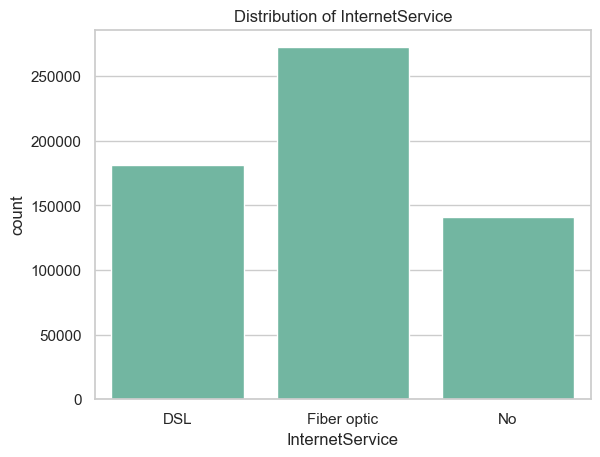

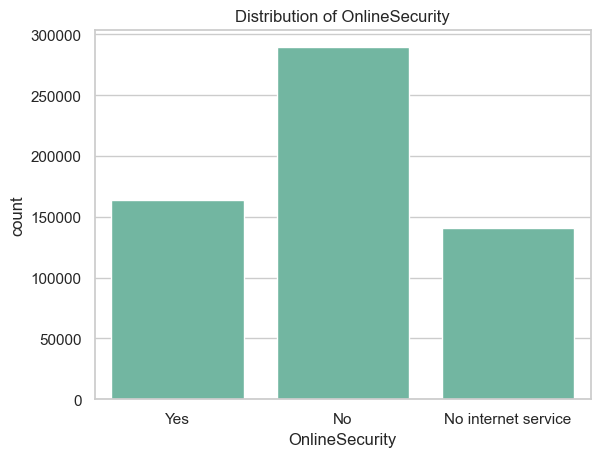

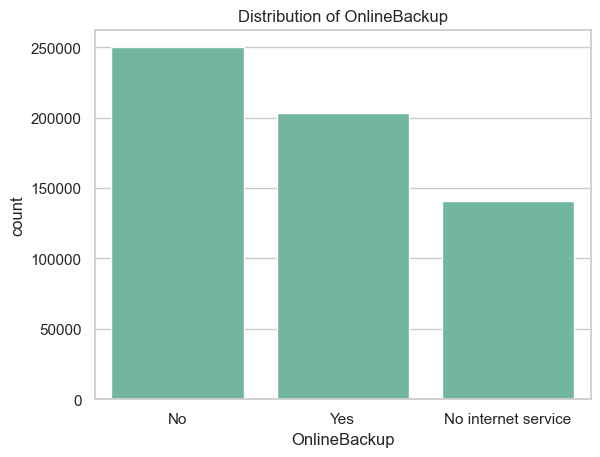

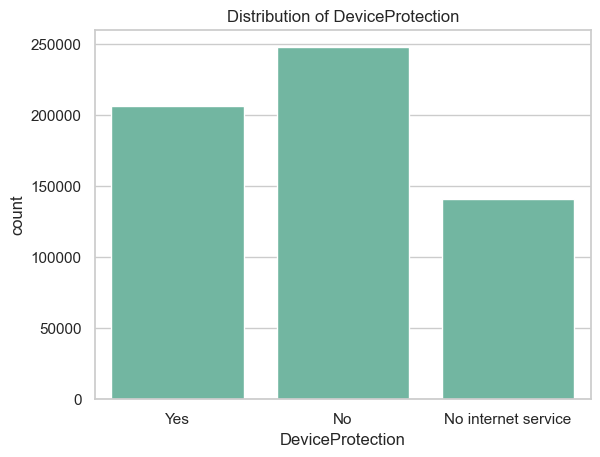

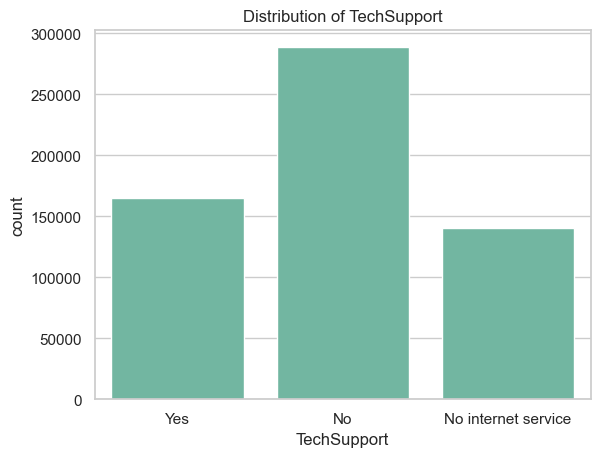

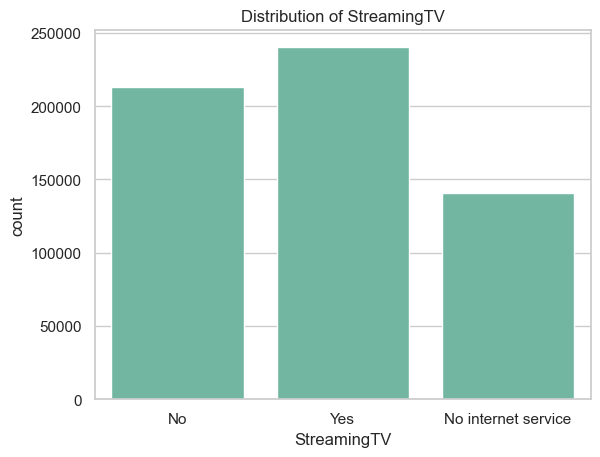

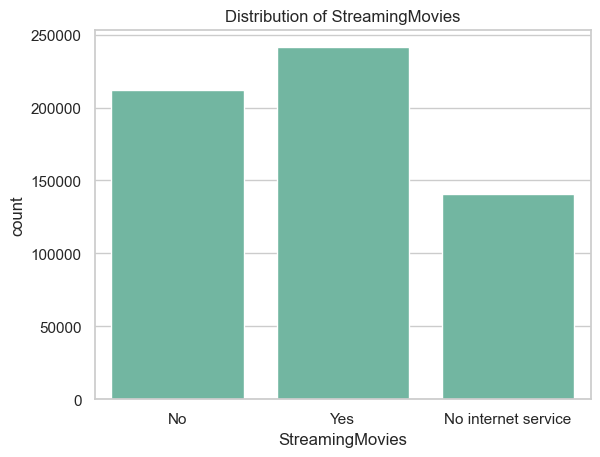

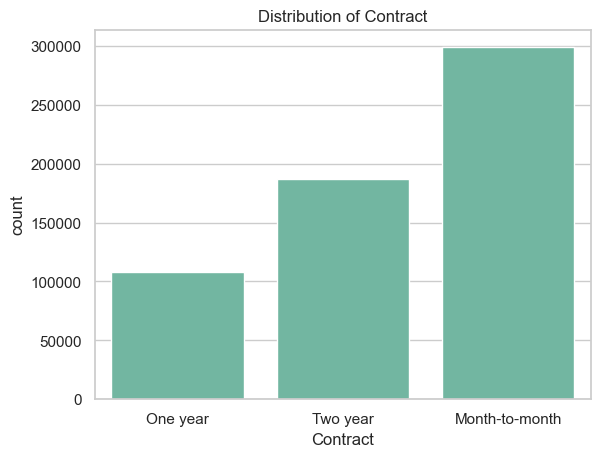

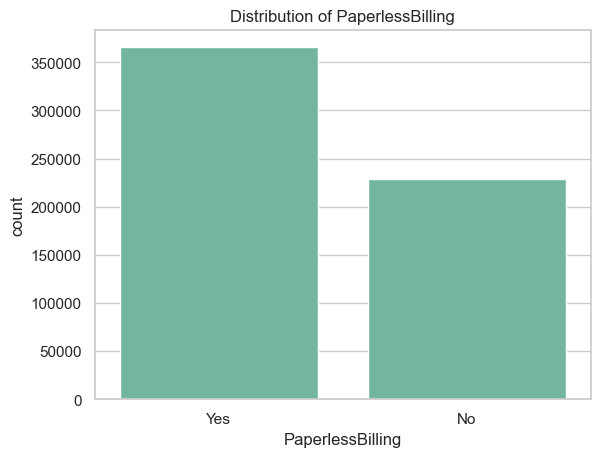

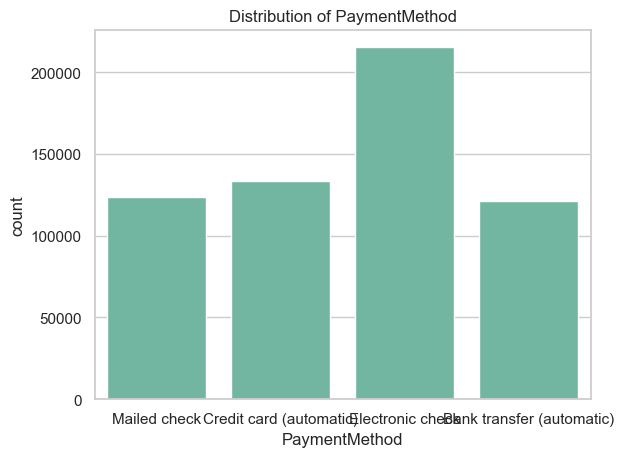

In [32]:
categorical_variables = ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']
for col in categorical_variables:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

## Numeric Variables vs Churn
Comparing tenure, MonthlyCharges, and TotalCharges between customers who churned and those who stayed.

- Customers who churn tend to have lower tenure, leaving early rather than staying long-term.
- Churned customers tend to pay higher MonthlyCharges, suggesting pricing may contribute to dissatisfaction.
- Customers who stay have higher TotalCharges overall, since they've accumulated charges over a longer tenure.

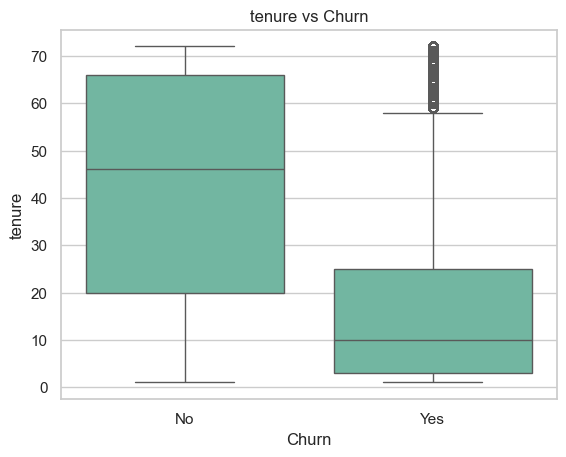

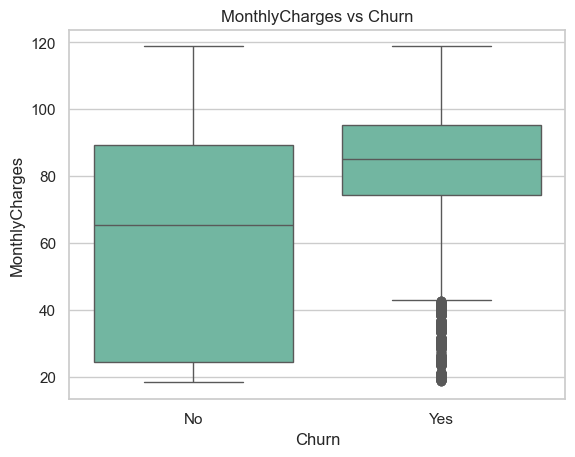

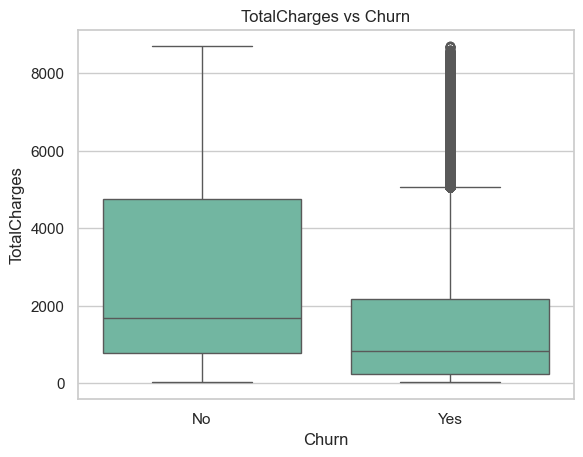

In [34]:
numeric_variables = ['tenure', 'MonthlyCharges', 'TotalCharges']
for variable in numeric_variables:
    sns.boxplot(x="Churn", y=variable, data=df)
    plt.title(f"{variable} vs Churn")
    plt.show()

## Categorical Variables vs Churn
Comparing churn rates across categories like Contract type and PaymentMethod.

- Month-to-month contract customers churn far more than those on one-year or two-year contracts.
- Customers paying via electronic check have a noticeably higher churn rate than other payment methods.

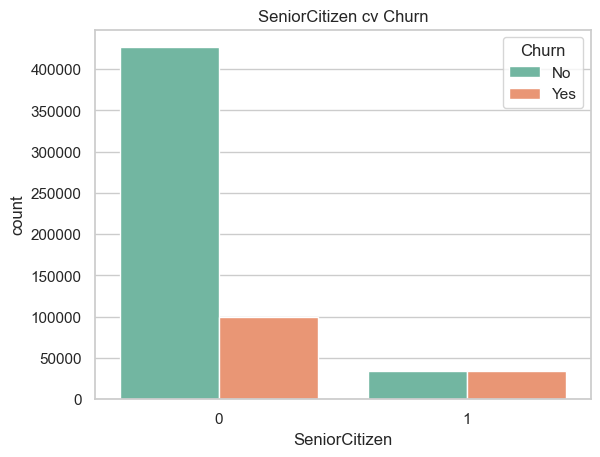

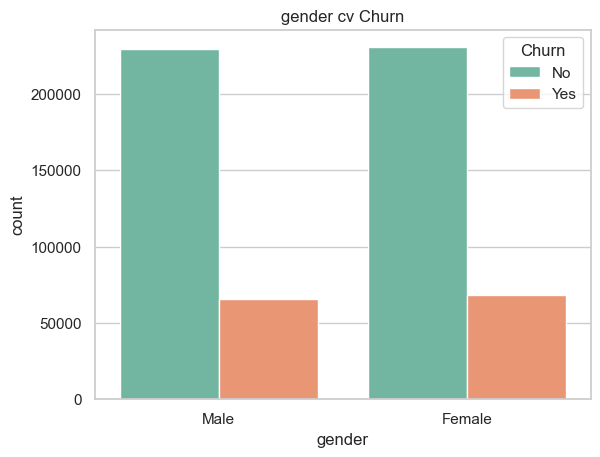

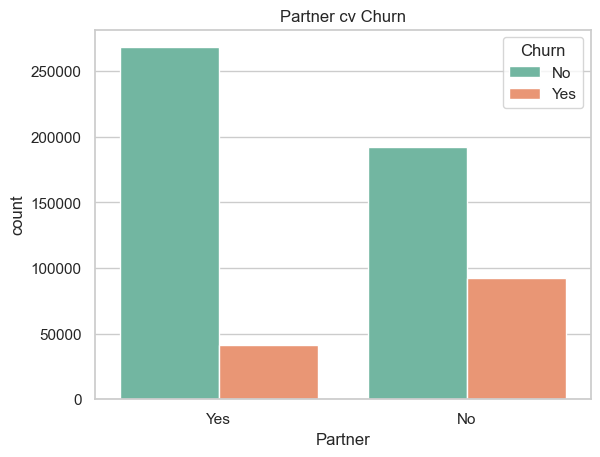

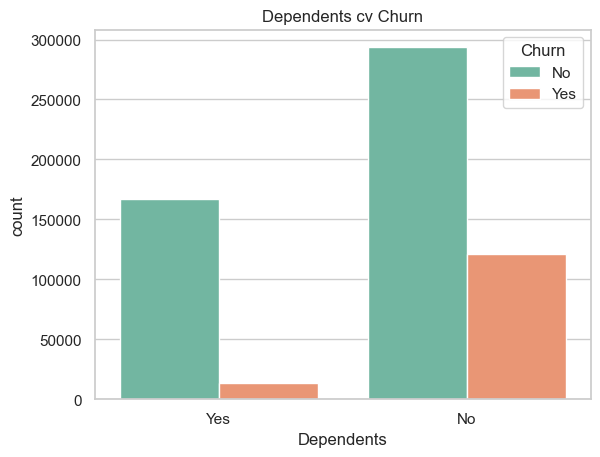

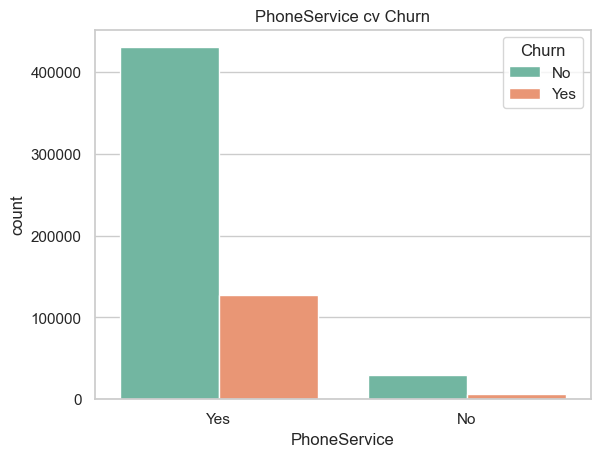

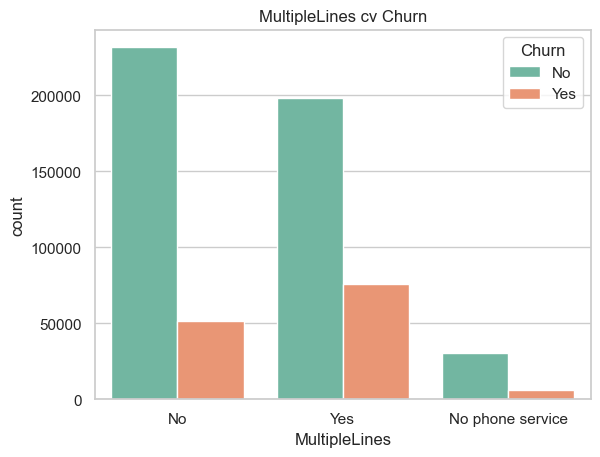

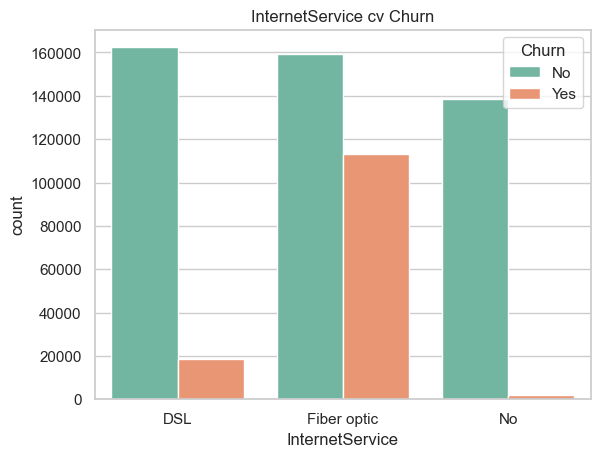

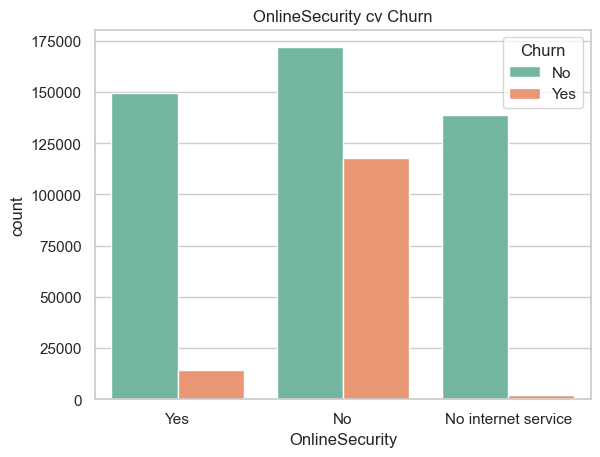

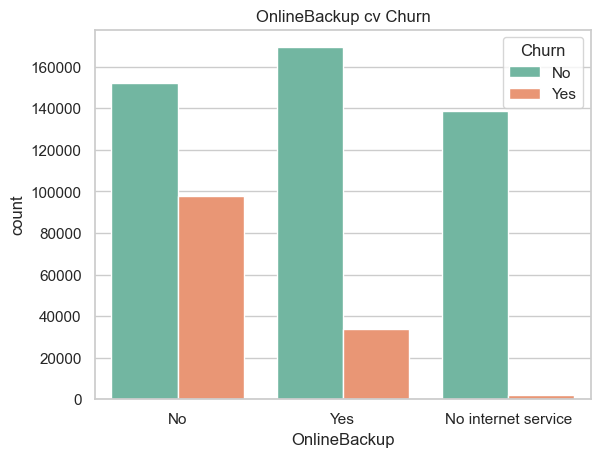

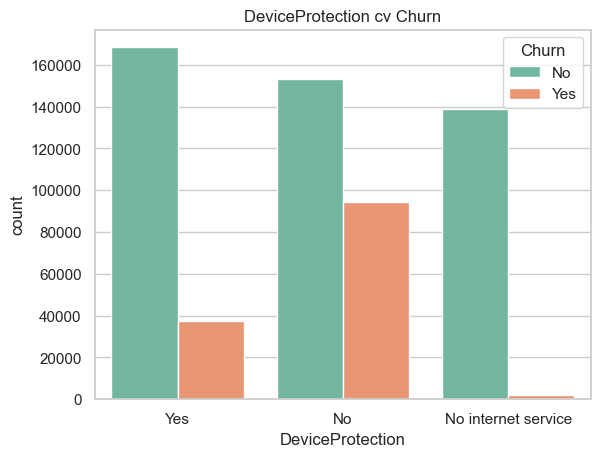

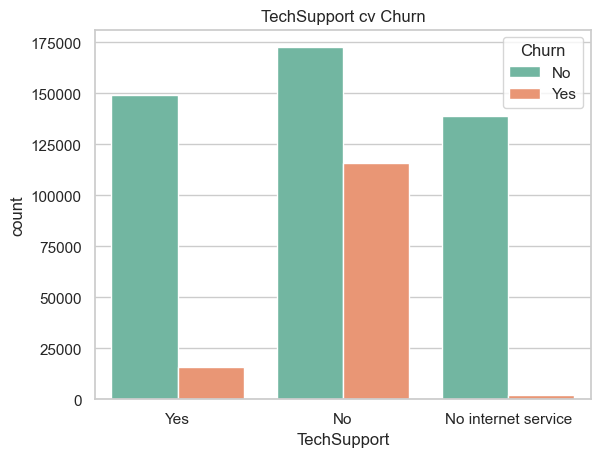

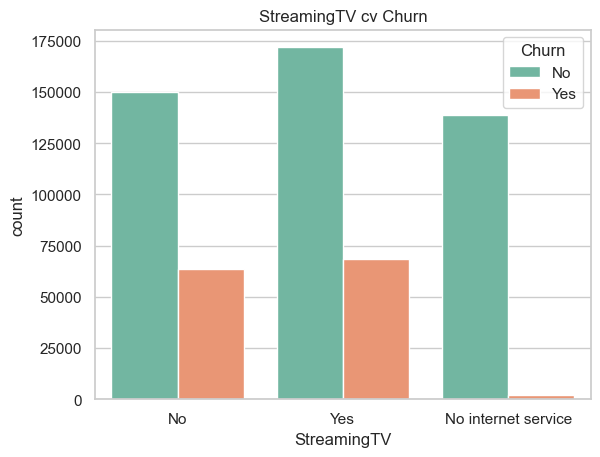

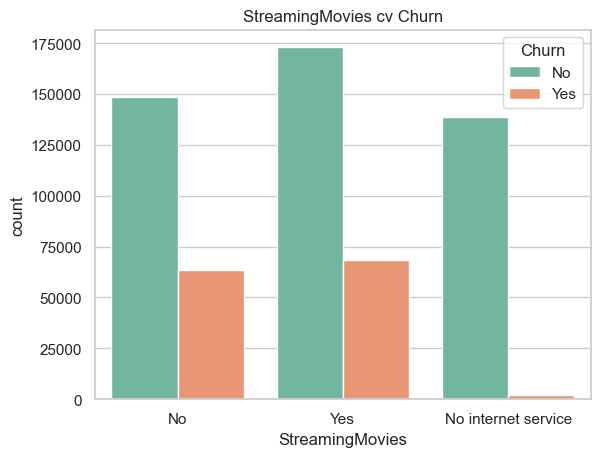

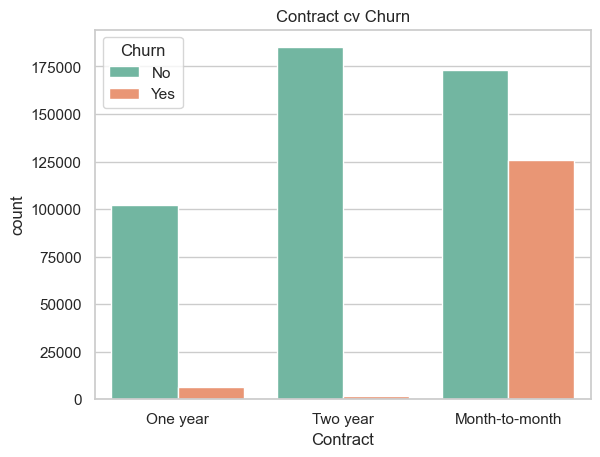

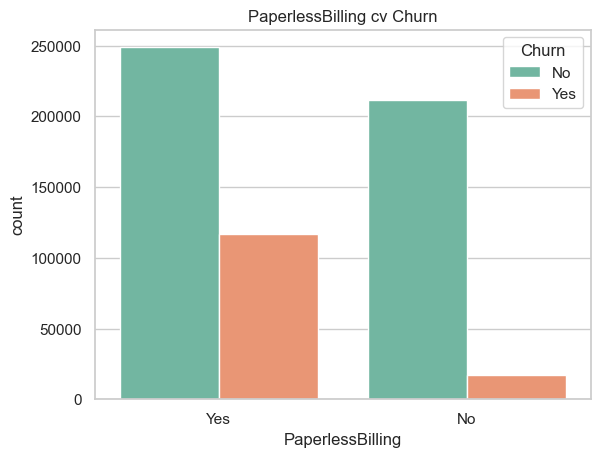

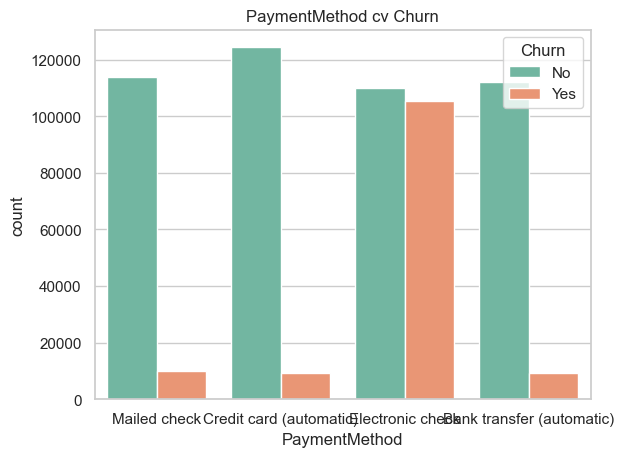

In [36]:
categorical_variables = ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']
for variable in categorical_variables:
    sns.countplot(data=df, x=variable, hue="Churn")
    plt.title(f"{variable} cv Churn")
    plt.show()

## Correlation Between Numeric Features
Checking how tenure, MonthlyCharges, and TotalCharges relate to one another.

- Tenure and TotalCharges show a strong positive correlation — longer-staying customers accumulate higher total charges.
- MonthlyCharges and TotalCharges show a moderate positive correlation.
- Tenure and MonthlyCharges show weak correlation — how long someone stays isn't strongly tied to what they pay monthly.

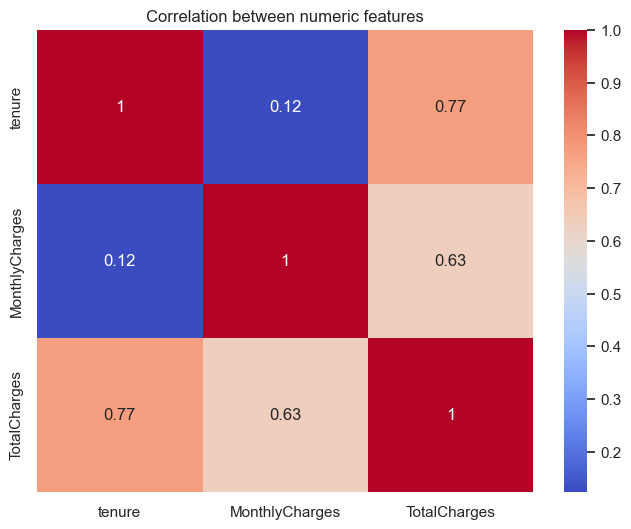

In [37]:
numeric_variables = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_variables].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between numeric features")
plt.show()

## Key Takeaways
- Churn happens early: most customers who leave do so within their first few months of tenure.
- Higher MonthlyCharges are associated with higher churn, suggesting price sensitivity.
- Contract type is a strong predictor — month-to-month customers churn far more than those on longer contracts.
- Customers paying via electronic check churn more than those using other payment methods.
- Long-tenure customers (70+ months) are unlikely to churn, suggesting loyalty builds significantly over time.